In [2]:
import pandas as pd
import regex as re
import numpy as np
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import pickle
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


## EDA

## Definición del problema

Queremos implementar un sistema que sea capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.

## Recopilación de datos

> Dataset de [url_spam](https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv)

In [3]:
df = pd.read_csv('../data/raw/url_spam.csv')

## Análisis descriptivo

In [4]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   url      2999 non-null   object
 1   is_spam  2999 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 26.5+ KB


(2999, 2)

### Observaciones:
> - Existen un total de 2369 filas y dos columnas.
> - La columna `url` es de tipo object.
> - La columna `is_spam` es de tipo boolean .

## Limpieza de datos

In [5]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

> - 630 duplicados borrados.

In [6]:
df.isnull().sum()

url        0
is_spam    0
dtype: int64

> - No existen valores nulos.

## Preprocesar los enlaces

### Cleaning

In [7]:
def preprocess_text(text):
    text = text.lower()
    # Reemplaza el contenido de las etiquetas (tags) html por <>
    text = re.sub("</?.*?>", " <> ", text)
    # Reemplaza aquello que no es una letra (a-z) o un espacio en blanco por un espacio en blanco
    text = re.sub(r'[^a-z ]', " ", text)
    # Reemplaza múltiples espacios en blanco en uno solo
    text = re.sub(r'\s+', " ", text)
    return text.split()

df['url'] = df['url'].apply(preprocess_text)
df.head()

,url,is_spam
0,"[https, briefingday, us, list, manage, com, un...",True
1,"[https, www, hvper, com]",True
2,"[https, briefingday, com, m, v, n, i, f]",True
3,"[https, briefingday, com, n, m, commentform]",False
4,"[https, briefingday, com, fan]",True


### Lematización

In [8]:
# Instancia lematizador
download("wordnet")
lemmatizer = WordNetLemmatizer()

download("stopwords")
stop_words = stopwords.words("english")

def lemmatize_text(words, lemmatizer=lemmatizer):
    # lematiza
    tokens = [lemmatizer.lemmatize(word) for word in words]
    # saca stop words
    tokens = [word for word in tokens if word not in stop_words]
    # se queda con las de largo mayor a
    tokens = [word for word in tokens if len(word) > 2]
    return tokens

[nltk_data] Downloading package wordnet to /home/vscode/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /home/vscode/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
df['url'] = df['url'].apply(lemmatize_text)
df.head()

,url,is_spam
0,"[http, briefingday, list, manage, com, unsubsc...",True
1,"[http, www, hvper, com]",True
2,"[http, briefingday, com]",True
3,"[http, briefingday, com, commentform]",False
4,"[http, briefingday, com, fan]",True


> - Se ha convertido diferentes formas de una palabra a su lema.
> - Las que no estan en la lista de stop_words, palabras vacías del inglés.
> - Se ha mantenido las palabras con un numero superior de 3 carácteres.


### Construir el Corpus Limpio.

Aplanamiento (Flattening).

In [10]:
tokens_list = df["url"]
tokens_list = [" ".join(tokens) for tokens in tokens_list]

## Visualización 

### Nube de palabras

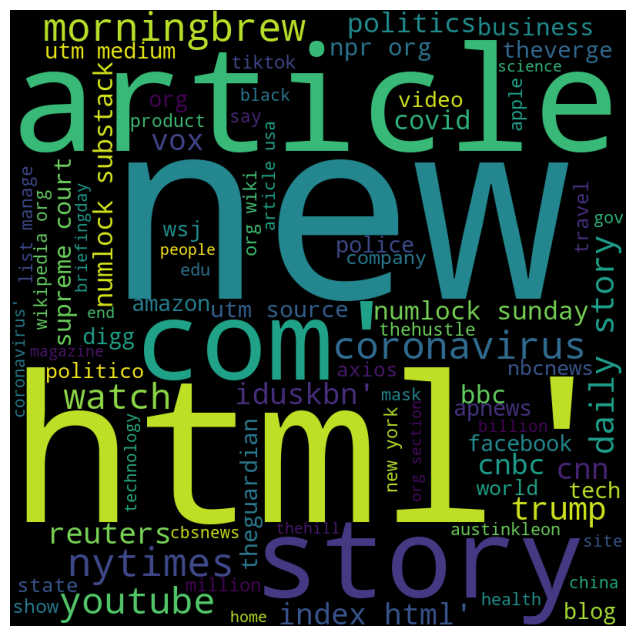

In [11]:
wordcloud = WordCloud(width=800,
                      height=800,
                      background_color="black",
                      max_words=1000,
                      min_font_size=20,
                      random_state=18).generate(str(tokens_list))

fig = plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

#### Observaciones:
> - La nueva nube está claramente dominada por temas de Noticias, Política y Tecnología.
> - Se encuentran también palabras muy generales en mensajes como html, articles, etc.

### Nube de Palabras por Categoría (Spam vs No-Spam)

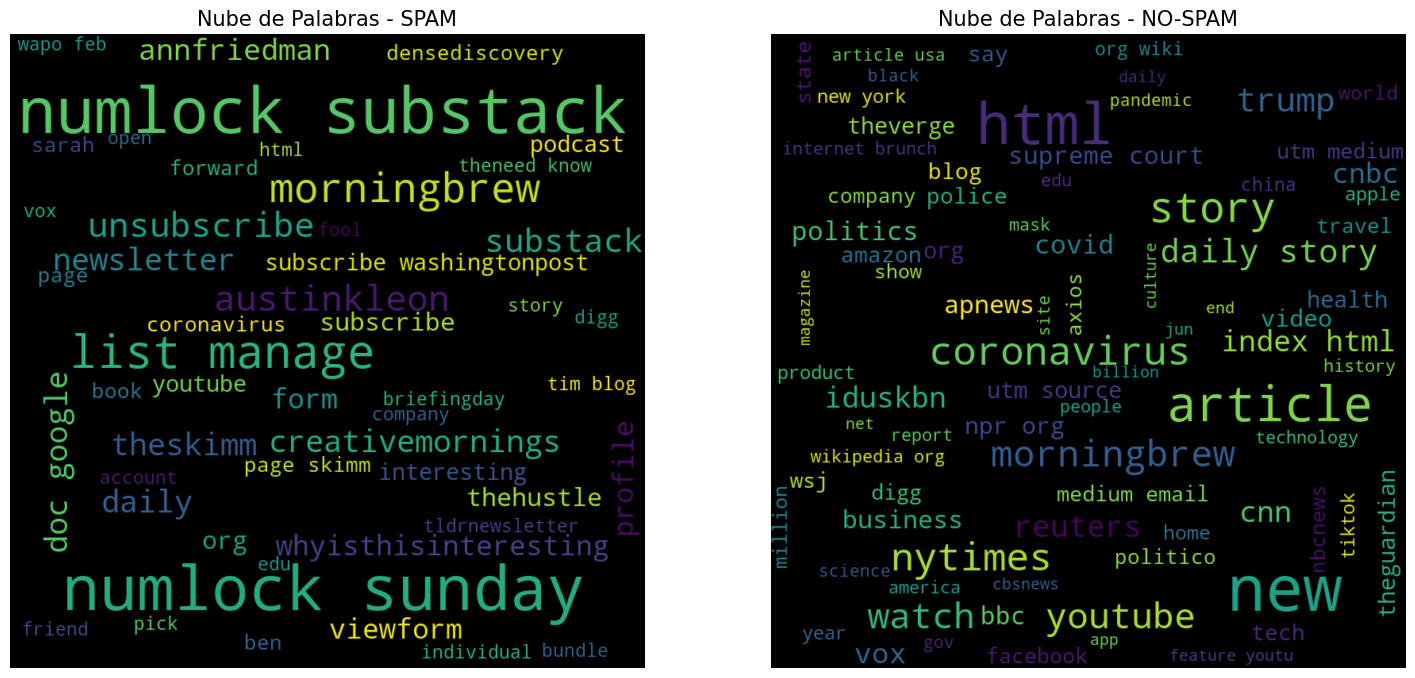

In [12]:
mask_spam = df['is_spam'] == True
mask_non_spam = df['is_spam'] == False

spam_tokens = [token for sublist in df[mask_spam]['url'] for token in sublist]
corpus_spam = " ".join(spam_tokens)


non_spam_tokens = [token for sublist in df[mask_non_spam]['url'] for token in sublist]
corpus_non_spam = " ".join(non_spam_tokens)

#GENERACIÓN DE NUBES DE PALABRAS
wordcloud_params = {
    'background_color': 'black',
    'width': 800,
    'height': 800,
    'min_font_size':20,
    'max_font_size':80,
    'max_words': 100
}

wordcloud_spam = WordCloud(**wordcloud_params).generate(corpus_spam)

wordcloud_non_spam = WordCloud(**wordcloud_params).generate(corpus_non_spam)


#VISUALIZACIÓN

plt.figure(figsize=(18, 9))

#Subplot para SPAM
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title('Nube de Palabras - SPAM', fontsize=15)
plt.axis("off")

#Subplot para NO-SPAM
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_non_spam, interpolation='bilinear')
plt.title('Nube de Palabras - NO-SPAM', fontsize=15)
plt.axis("off")

plt.show()

##### Observaciones:
> - NO-SPAM: Está fuertemente caracterizado por nombres de medios de noticias y plataformas legítimas (nytimes, reuters, youtube)
> - SPAM: Está dominado por tokens relacionados con la gestión de correo masivo (unsubscribe, list manage, newsletter) y el uso de formularios o documentos (viewform, doc google)

### Vectorizar

In [13]:
vectorizer = TfidfVectorizer(max_features=5000,
                             max_df=0.8,
                             min_df=5)

#Feature Engineering (Transformación y Etiqueta)
X = vectorizer.fit_transform(tokens_list).toarray()
y = df["is_spam"]

X[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 613))

In [14]:
X.shape

(2369, 613)

> - Cada fila es una URL y cada columna es una palabra, llena de valores numéricos de TF-IDF.

## Construye un SVM

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)
model = SVC(kernel="linear",
            random_state=18)
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
y_pred = model.predict(X_test)
y_pred

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False,  True, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False,

In [17]:
accuracy_score(y_test, y_pred)

0.9219409282700421

#### Reporte de clasificación del modelo SVC

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.93      0.99      0.96       421
        True       0.83      0.38      0.52        53

    accuracy                           0.92       474
   macro avg       0.88      0.68      0.74       474
weighted avg       0.92      0.92      0.91       474



#### Obervaciones:
> - El modelo muestra una alta precisión general (0.92).
> - La sensibilidad para Spam es muy baja(0.38), al igual que su rendimiento f1-score(0.52).
> - Existe un claro desbalance entre no-spam con 421 muestras y spam con 53.

#### Matriz de confusión

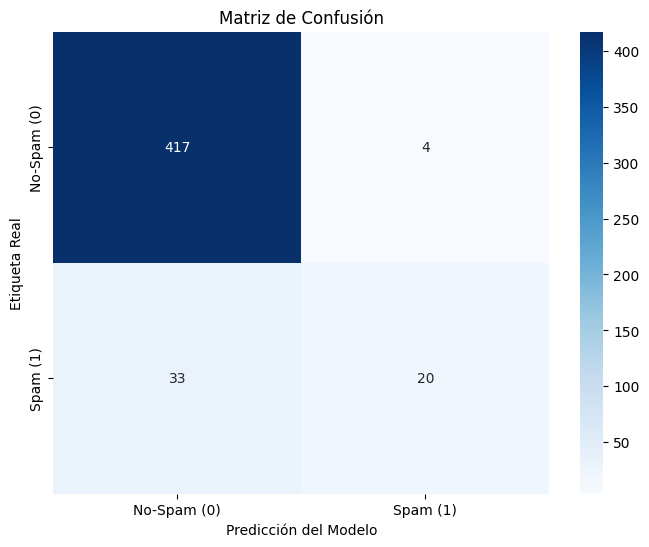

In [19]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No-Spam (0)', 'Spam (1)'],
            yticklabels=['No-Spam (0)', 'Spam (1)'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión')
plt.show()

##### Observaciones:
> - Hay 417 verdaderos negativos y 33 falsos negativos
> - Hay 20 verdaderos positivos y 4 falsos positivos

## Optimiza el modelo anterior

In [20]:
hyperparams = {'C': np.logspace(-3, 2, 6),
               "kernel": ["linear", "poly", "rbf", "sigmoid", "precomputed’"],
               "degree": [1, 2, 3, 4, 5],
               "gamma": ["scale", "auto"],
               'class_weight':['balanced']
               }

grid = GridSearchCV(model,
                    hyperparams,
                    scoring="accuracy",
                    cv=5)
grid

,estimator,SVC(kernel='l...ndom_state=18)
,param_grid,"{'C': array([1.e-03...e+01, 1.e+02]), 'class_weight': ['balanced'], 'degree': [1, 2, ...], 'gamma': ['scale', 'auto'], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1.0


In [21]:
grid.fit(X_train, y_train)
grid.best_params_

/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
300 fits failed out of a total of 1500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
300 fits failed with the following error:
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/vscode/.local/lib/python3.11/site-packages/sklearn/base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "/home/vscode/.l

{'C': np.float64(10.0),
 'class_weight': 'balanced',
 'degree': 1,
 'gamma': 'auto',
 'kernel': 'rbf'}

#### Entrenamiento del modelo optimizado con las clases balanceadas.

In [22]:
model_opt = SVC(C=1.0, 
                 degree=1,
                 gamma="scale",
                 kernel="linear",
                 class_weight='balanced',
                 random_state=18
                 )

model_opt.fit(X_train, y_train)
y_pred_opt = model_opt.predict(X_test)

accuracy_score(y_test, y_pred_opt)

0.8481012658227848

##### Observaciones:
> - Obtengo una precisión mas baja de (-0.08) puntos respecto al modelo base.
> - En el output para best_params se puede observar como muestra la combinación de parámetros como la mejor optimización del modelo, opte por ignorar esta sugerencia en favor de la configuración SVC(..., class_weight='balanced') tras la experimentación empírica.

#### Reporte de clasificación del modelo SVC

In [23]:
print(classification_report(y_test, y_pred_opt))

              precision    recall  f1-score   support

       False       0.97      0.86      0.91       421
        True       0.40      0.75      0.53        53

    accuracy                           0.85       474
   macro avg       0.68      0.81      0.72       474
weighted avg       0.90      0.85      0.87       474



#### Observaciones:
> - La Sensibilidad (Recall) para la clase Spam (True) mejoró mucho de (0.38) a (0.75).
> - El modelo muestra una alta precisión general (0.92).
> - La rescisión del Spam cae de (0.83) a (0.40), el recall de no-Spam cae de (0.99) a (0.86) esto es un aumento en los falsos positivos, ya que el modelo ahora está sesgado y ser más cauteloso y clasificar mas URL como Spam.

#### Matriz de confusión

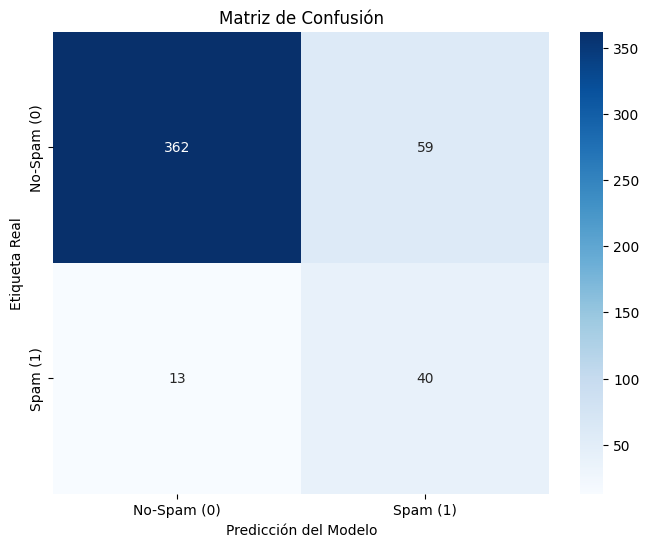

In [24]:
cm_opt = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No-Spam (0)', 'Spam (1)'],
            yticklabels=['No-Spam (0)', 'Spam (1)'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión')
plt.show()

##### Observaciones:
> - Hay 362 verdaderos negativos y 13 falsos negativos en comparación a los 33 del modelo anterior.
> - Hay 40 verdaderos positivos y 59 falsos positivos, 55 mas que el modelo base.

## Guarda el modelo

In [26]:
with open('../models/svm_model.pkl', 'wb') as file:
    pickle.dump(model_opt, file)

## Conclusiones:
> 1. El Modelo Optimizado (SVC con class_weight='balanced') fue seleccionado como el modelo final porque está estratégicamente sesgado para priorizar la seguridad del usuario.
> 2. El costo de que una URL de Spam se escape (Falso Negativo) es mayor que el costo de bloquear un contenido legítimo (Falso Positivo).